In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('PEA04.20231018T191000.csv')
df.head()

,STATISTIC Label,Year,Age Group,Sex,Region,UNIT,VALUE
0,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,State,Thousand,356.0
1,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Border,Thousand,30.7
2,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,West,Thousand,32.6
3,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Mid-West,Thousand,35.0
4,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,South-East,Thousand,32.0


In [3]:
df.shape

(6669, 7)

In [4]:
df.isna().sum()

STATISTIC Label    0
Year               0
Age Group          0
Sex                0
Region             0
UNIT               0
VALUE              0
dtype: int64

In [5]:
df.dtypes

STATISTIC Label     object
Year                 int64
Age Group           object
Sex                 object
Region              object
UNIT                object
VALUE              float64
dtype: object

In [6]:
df.describe()

,Year,VALUE
count,6669.000000,6669.000000
mean,2017.000000,75.670460
std,3.741938,281.512172
min,2011.000000,1.200000
25%,2014.000000,12.500000
50%,2017.000000,20.700000
75%,2020.000000,42.200000
max,2023.000000,5281.600000


In [7]:
df.columns

Index(['STATISTIC Label', 'Year', 'Age Group', 'Sex', 'Region', 'UNIT',
       'VALUE'],
      dtype='object')

In [8]:

# changing the columns name to make it easy to understand.
# inplace = True set the valuses parmently so that we can use the new columns names
df.rename(columns={'STATISTIC Label': 'statistic_label', 'Year': 'year', 'Age Group':'age_group', 'Sex':'sex', 'Region':'region', 'UNIT':'unit','VALUE':'value'},inplace=True)

In [9]:
df.head()

,statistic_label,year,age_group,sex,region,unit,value
0,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,State,Thousand,356.0
1,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Border,Thousand,30.7
2,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,West,Thousand,32.6
3,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,Mid-West,Thousand,35.0
4,Estimated Population (Persons in April),2011,0 - 4 years,Both sexes,South-East,Thousand,32.0


In [10]:
#now drop tha table one that is "statistic_label" because there is no any usefull data only text is reperting throught the table  so eliminate it
df.drop({'statistic_label', 'unit'}, axis=1, inplace=True)

In [11]:
## and the valuse are in thousand to we multiply the values column in thousand
df['value'] = df['value']*1000

In [12]:
df.head()
#2011	0 - 4 years	Male	State

,year,age_group,sex,region,value
0,2011,0 - 4 years,Both sexes,State,356000.0
1,2011,0 - 4 years,Both sexes,Border,30700.0
2,2011,0 - 4 years,Both sexes,West,32600.0
3,2011,0 - 4 years,Both sexes,Mid-West,35000.0
4,2011,0 - 4 years,Both sexes,South-East,32000.0


In [13]:
filt1 = (df['age_group'] == '0 - 4 years') & (df['sex'] == 'Both sexes') & (df['region'] == 'State')

In [14]:
pop_2011 = df.loc[filt1]
pop_2011.loc[pop_2011['year']==2023, 'value']

6156    293800.0
Name: value, dtype: float64

In [15]:
import matplotlib.pyplot as plt

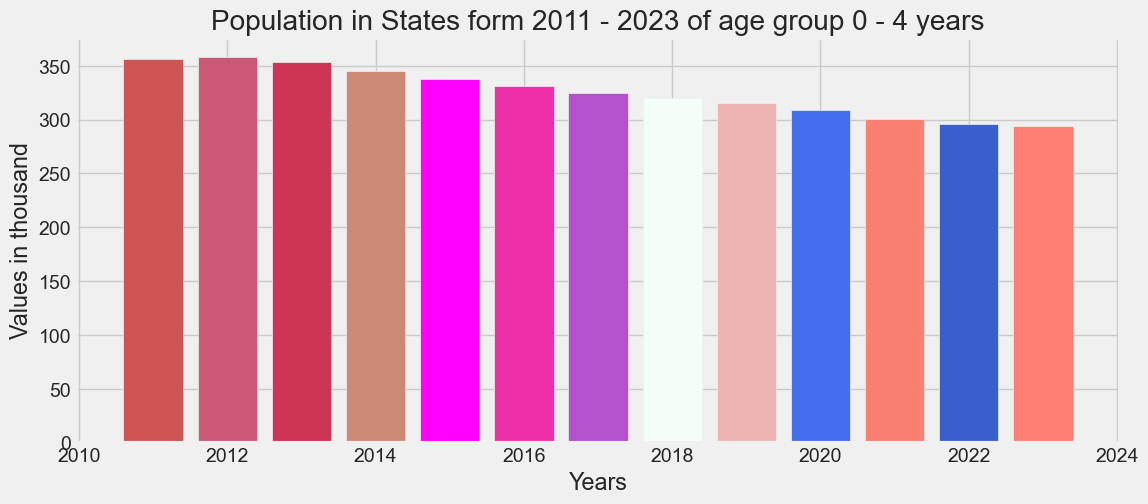

In [50]:
fig, BarGraph = plt.subplots(figsize=(12, 5))
bar_colors = ['#CD5555','#CD5777','#CD3455','#CD8977', '#FF00FF', '#EE30A7', '#B452CD', '#F5FFFA','#EEB4B4', '#436EEE', '#FA8072', '#3A5FCD', '#FF8072']
BarGraph.bar(pop_2011['year'], pop_2011['value']/1000, color = bar_colors)
plt.style.use('fivethirtyeight')
plt.xlabel('Years')
plt.ylabel('Values in thousand')
plt.title("Population in States form 2011 - 2023 of age group 0 - 4 years")
plt.show()


In [17]:
# we can see that there is slightly decrease in population for 2011 to 2023 which indicate that the birth rate has decresed by
#now calculate the change
state_pop1 = pop_2011.loc[pop_2011['year']==2023, 'value'].reset_index(drop=True)
state_pop2 = pop_2011.loc[pop_2011['year'] == 2011, 'value'].reset_index(drop=True)
pop_dec_per_state = ((state_pop1-state_pop2)/state_pop2)*100

In [24]:
pop_dec_per_state
#it state that birth rate is decresed by 17 % in 12 years

0   -17.47191
Name: value, dtype: float64

In [26]:
every_year_decreased = -17.47191 / 12
every_year_decreased
# about 1.4559925 % the birth rate is decreasing every year

-1.4559925

In [40]:
state_filt = (df['sex'] == 'Both sexes') & (df['region'] == 'State') & (df['age_group'] == 'All ages')
state_pop = df.loc[state_filt]


In [41]:
state_pop.shape

(13, 5)

In [42]:
state_pop

,year,age_group,sex,region,value
486,2011,All ages,Both sexes,State,4574900.0
999,2012,All ages,Both sexes,State,4593700.0
1512,2013,All ages,Both sexes,State,4614700.0
2025,2014,All ages,Both sexes,State,4645400.0
2538,2015,All ages,Both sexes,State,4687800.0
3051,2016,All ages,Both sexes,State,4739600.0
3564,2017,All ages,Both sexes,State,4810900.0
4077,2018,All ages,Both sexes,State,4884900.0
4590,2019,All ages,Both sexes,State,4958500.0
5103,2020,All ages,Both sexes,State,5029900.0


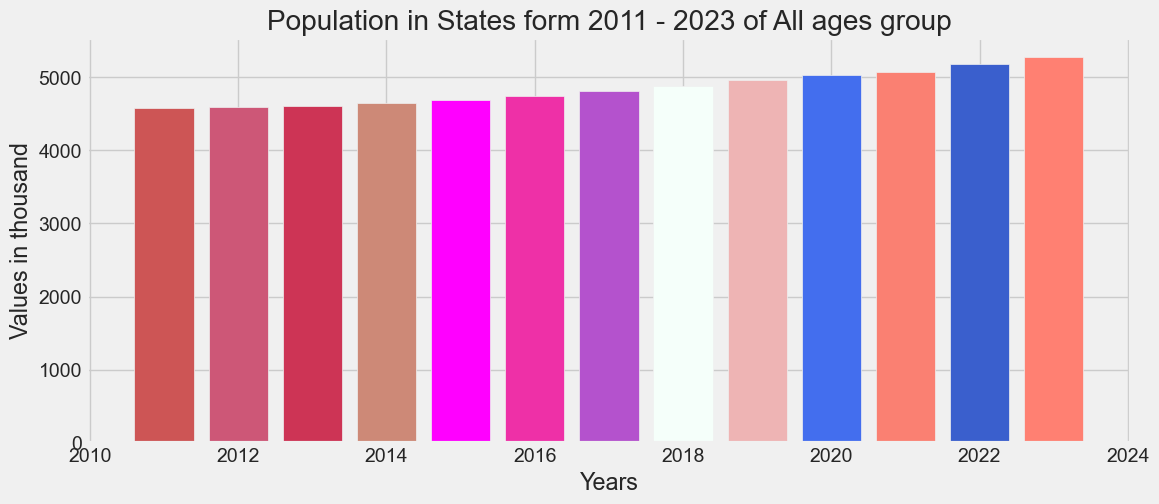

In [49]:
#total population in each year form 2011 to 2023
fig, BarGraph = plt.subplots(figsize=(12, 5))
bar_colors = ['#CD5555','#CD5777','#CD3455','#CD8977', '#FF00FF', '#EE30A7', '#B452CD', '#F5FFFA','#EEB4B4', '#436EEE', '#FA8072', '#3A5FCD', '#FF8072']
BarGraph.bar(state_pop['year'], state_pop['value']/1000, color = bar_colors)
plt.style.use('fivethirtyeight')
plt.xlabel('Years')
plt.ylabel('Values in thousand')
plt.title("Population in States form 2011 - 2023 of All ages group")
plt.show()